In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

/home/lokesh/anaconda3/envs/IRC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

Checkpoint (epoch 400) loaded.
Fetching the most trained agent so far (epoch 400).
Agent (seed 0) was trained for 400 epochs, RL optimality 100.00%.


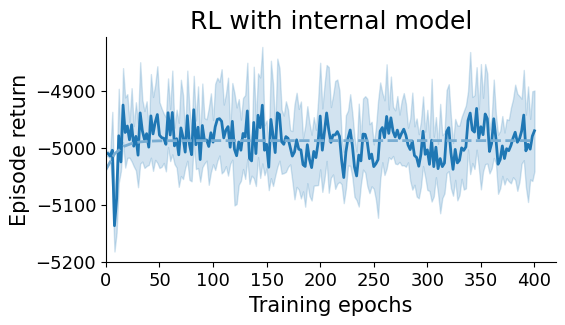

In [3]:
env_param = [-3.0, 200.0, .08, .25, -5000, 0]

# change back to old no. of epochs
# num_epochs = 369
num_epochs = 400

agent = manager.train_agent(env_param, num_epochs=num_epochs)
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

problem somwhere here
[[3]
 [0]
 [0]
 ...
 [0]
 [0]
 [2]]
(array([4478]), array([0]))
problem somwhere here
[[3]
 [0]
 [1]
 ...
 [1]
 [1]
 [2]]
(array([4478]), array([0]))


{'agent': {'lick_cost': -3.0,
  'food_reward': 200.0,
  'attention_cost_coeff': 0.08,
  'attention_cost_temp': 0.25,
  'penalty_cost': -5000,
  'iti_cost': 0,
  'no_attention_modes': 3},
 'experiment': {'prob_01': 0.004,
  'no_signal_nodes': 150,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 1}}

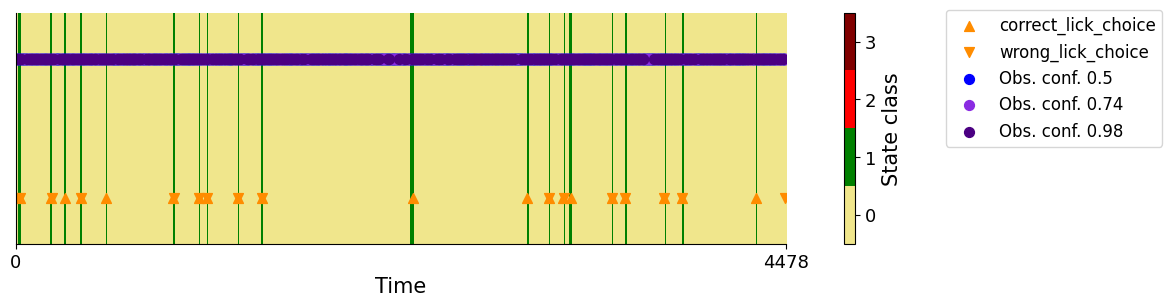

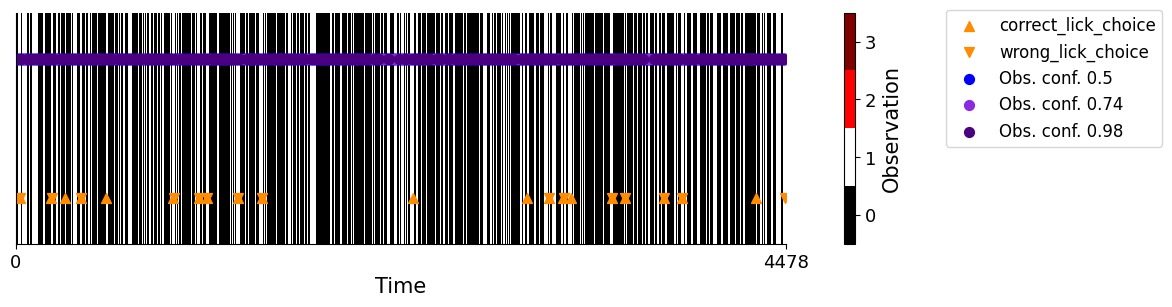

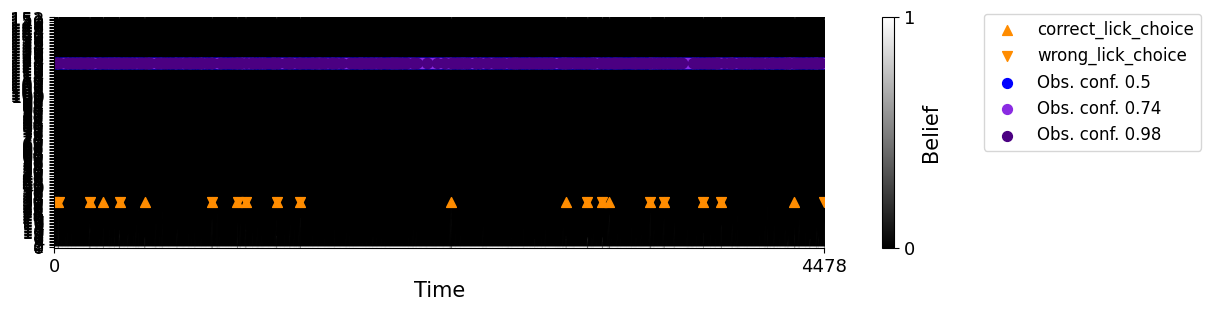

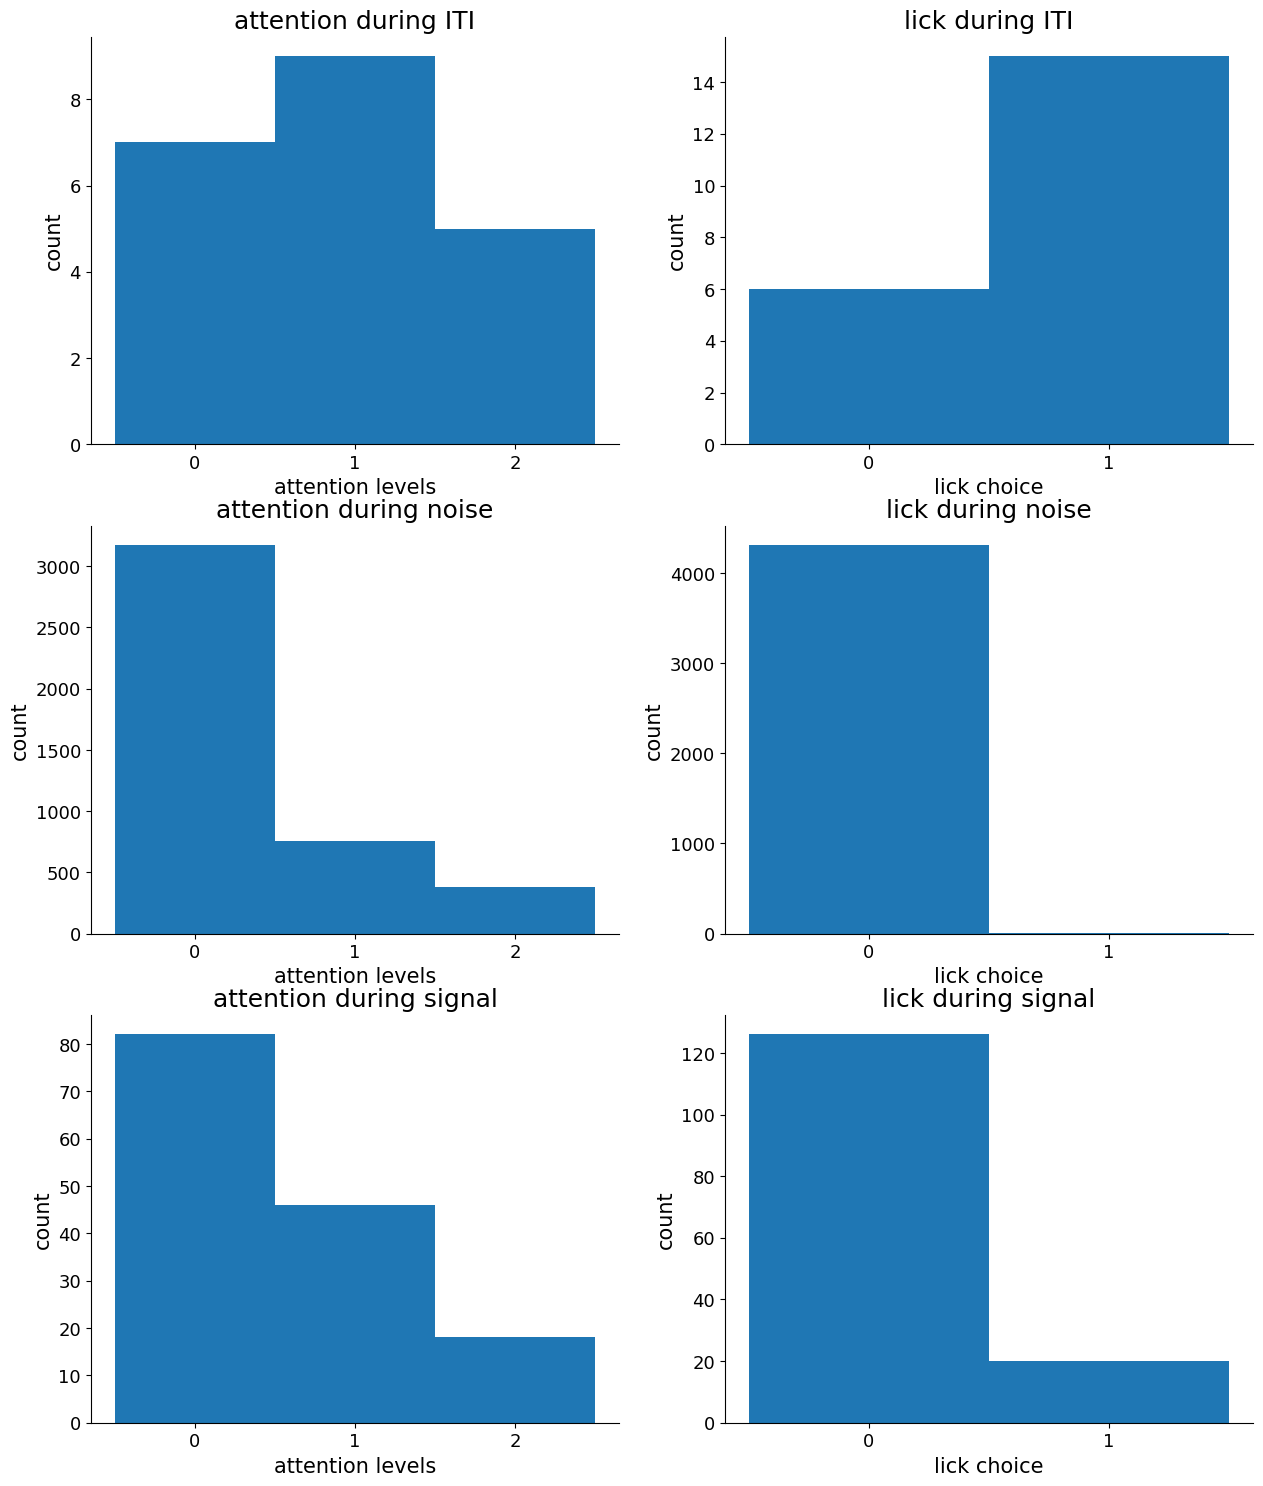

In [5]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

env.spec

# Particle filter

## Running Particle filter

In [9]:
from auditoryforage.particle_filter import ParticleFilter
end_index = 5
no_particles_list = [10000]
sampling_freq_list = [1]
particle_filter = ParticleFilter(agent, env)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

Filter with no_particles = 10000 and sampling_freq = 1 in action.
Saved data to file store/particle_filter/PF_np_10000_sf_1_ei_5_rn_86.pkl.


## Particle filter generated episode

In [ ]:
from auditoryforage.particle_filter import ParticleFilter
PF_file_name = 'store/particle_filter/PF_np_10000_sf_1_ei_1_rn_21.pkl'
likelihood_rank = 0
particle_filter = ParticleFilter(agent, env)
particle_filter.plot_generated_episode(file_name = PF_file_name, likelihood_rank = likelihood_rank)

## Analyzing particle filter output.

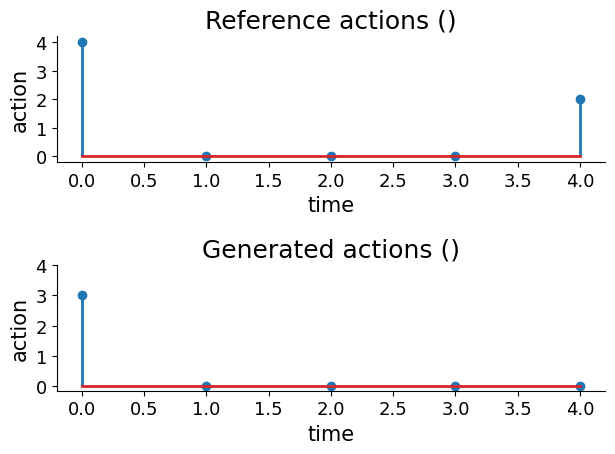

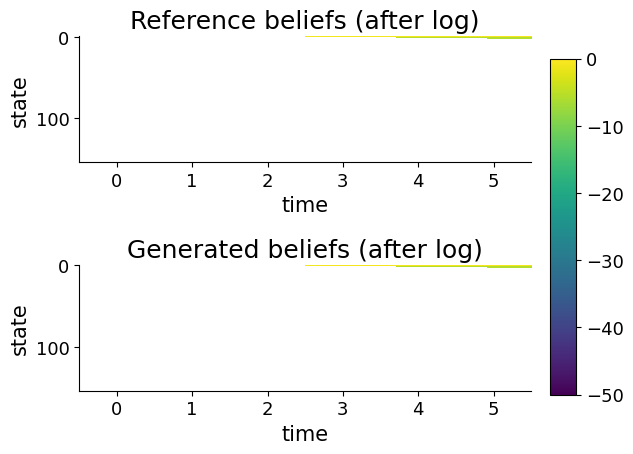

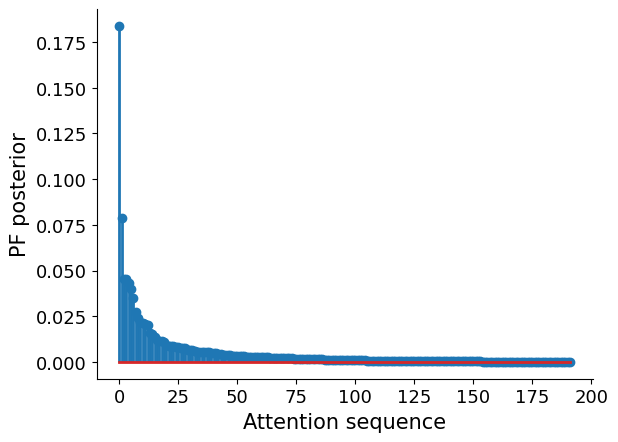

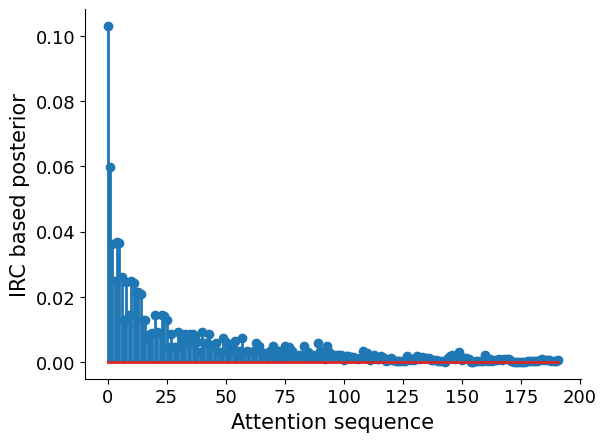

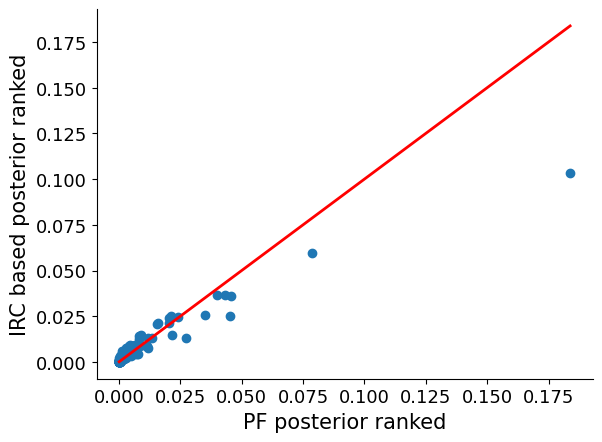

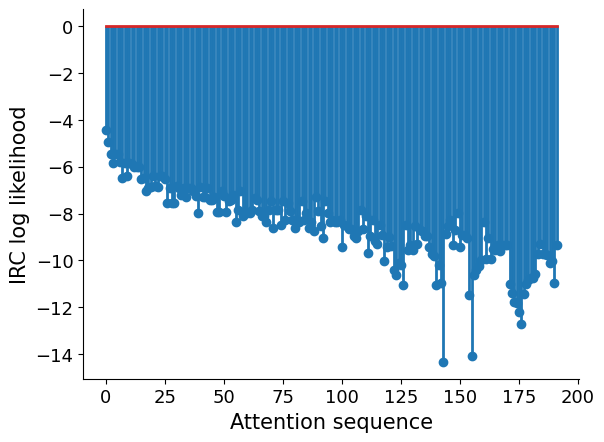

No sampling repetition was needed. Good stuff!


In [10]:
from auditoryforage.particle_filter import PF_results_analyzer
PF_file_name = 'store/particle_filter/PF_np_10000_sf_1_ei_5_rn_86.pkl'
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

## Computing attention posterior using HMM.

In [ ]:
from auditoryforage.attention_posterior import AttentionPosterior
end_index = 1
attention_posterior_IO = AttentionPosterior(agent, env, episode, end_index).compute_posterior_across_attention_series()

## Comparing particle filter and HMM outputs.

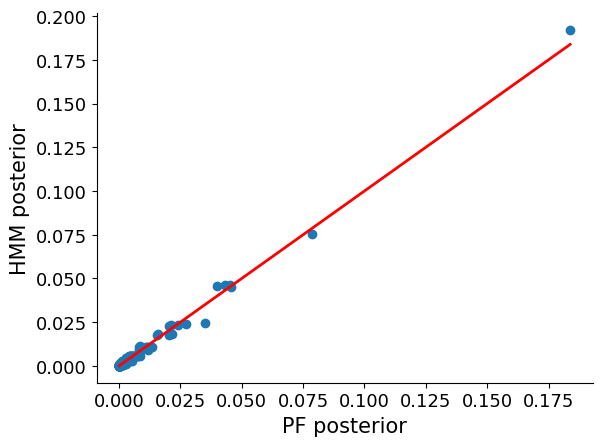

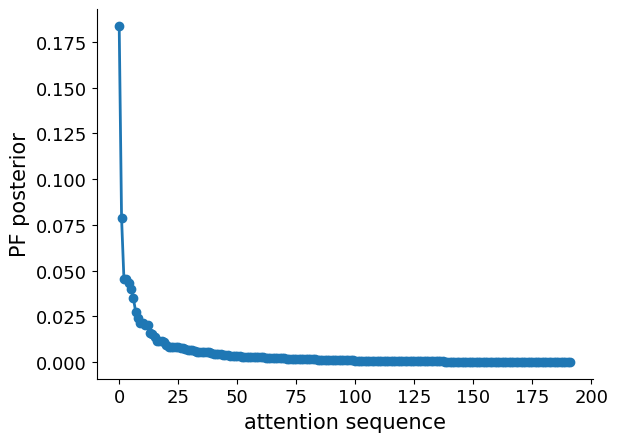

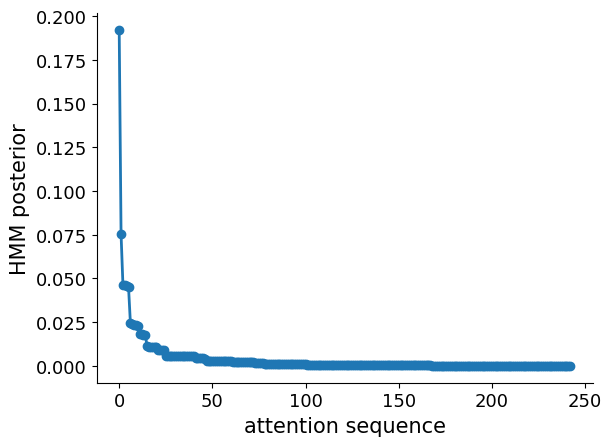

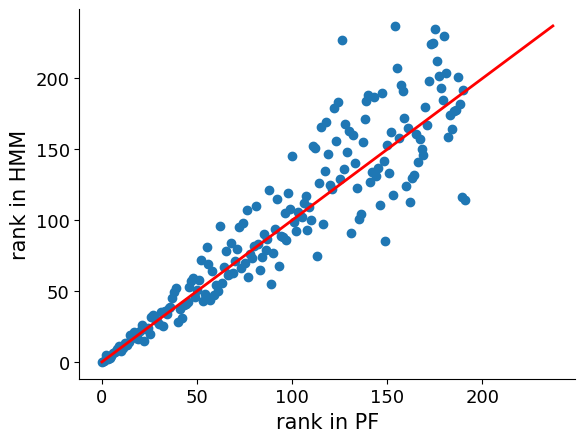

In [11]:
from auditoryforage.attention_posterior import compare_PF_HMM
PF_file_name = 'store/particle_filter/PF_np_10000_sf_1_ei_5_rn_86.pkl'
HMM_file_name = 'store/particle_filter/HMM_attention_series_posterior_ei_5_rn_44.pkl'
compare_PF_HMM(PF_file_name = PF_file_name, HMM_file_name = HMM_file_name)

In [ ]:
from auditoryforage.utils import open_pickle_file
PF_file_name = 'store/particle_filter/PF_np_10000_sf_1_ei_3_rn_14.pkl'
HMM_file_name = 'store/particle_filter/HMM_attention_series_posterior_ei_3_rn_11.pkl'
particle_filter_IO = open_pickle_file(PF_file_name)
attention_posterior_IO = open_pickle_file(HMM_file_name)
plt.stem(particle_filter_IO['output']['posterior']['posterior_ranked'])
plt.show()
particles_likelihoods = np.exp(particle_filter_IO['output']['particles_log_likelihoods'])
particles_likelihoods = particles_likelihoods/np.sum(particles_likelihoods)
plt.stem(particles_likelihoods)
plt.show()

In [ ]:
print(particle_filter_IO['output'].keys())